# Workshop figures — v3

Rebuilt against the *ensemble dispersion failure* spec. v2's figures were organised around a
single outcome-conditioned scaling panel; v3 is organised around the **two conditionings**,
because that is what carries the argument.

## The four moves

| # | move | conditioning | claims |
|---|---|---|---|
| 1 | failure under observed conditions | $y$ | consequence, not mechanism |
| 2 | confounders named and handled | $y$ + simulation | selection quantified, bias acknowledged |
| 3 | dispersion isolated | $\hat\mu$ | mechanism, identified |
| 4 | a better mean would not fix it | — | the contribution |

## What is new in v3

Everything the spec marked **TO COMPUTE** or listed under *outstanding computations*:

1. $\hat\mu$-conditioned decile profile, with basin-clustered bootstrap intervals.
2. Self-consistency null — kept as an appendix check only; the body argues selection
   analytically instead.
3. Per-basin break against **its own** simulated null rather than against 1.
4. Peak-bias-removed break, with a value.
5. Observation-error bound, expressed as a fraction of top-decile flow.
6. Bootstrap on the thin top levels of the $\hat\mu$ ladder.

## Statistic

Unit of analysis is the **basin-day**. The reported quantity is the ratio of realized error
to reported spread,

$$\text{ratio} \;=\; \frac{\operatorname{SD}\!\left[\,r \mid \mathcal{S}\,\right]}
{\sqrt{\overline{\hat\sigma_e^2}}\;\sqrt{(M+1)/M}},\qquad r = y-\hat\mu,\; M=10 .$$

The numerator is a **residual SD about the set's own mean**, not an RMSE. The denominator
pools in *variance* space and carries the finite-ensemble correction $\sqrt{11/10}=1.0488$.
**Aleatoric variance is excluded from the denominator** — this is a statement about
inter-member spread only, and must appear in body text, not just a caption.

In [1]:
import sys, json, pathlib
import numpy as np, pandas as pd

_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p/"src"/"config.py").exists()), None)
if _root is None: raise RuntimeError(f"project root not found from {pathlib.Path.cwd()}")
if str(_root) not in sys.path: sys.path.insert(0, str(_root))
from src.config import OUTPUT_DATA_DIR
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
FIG_OUT = _root/"figures"; FIG_OUT.mkdir(exist_ok=True)

idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy"); valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz"); mu = pred["mu_hat"]; sigma_e2 = pred["sigma_e2"]
M = json.loads((R/"meta.json").read_text())["n_members"]      # 10; sigma_e2 is ddof=1
CORR = np.sqrt((M+1)/M)
train = (split=="train"); test = (split=="test")
resid = y - mu; err2 = resid**2
NBAS = y.shape[1]; SEED = 0; B = 1000

def factor(m):
    """Ratio of residual SD to RMS ensemble spread, finite-ensemble corrected.
    sqrt(mean(sigma_e2)) == RMS(sigma_e); pooling is in variance space. NOT mean(sigma_e)
    (inflates ~1.4-1.9x), NOT RMS(sigma_e2) (a 4th moment)."""
    if m.sum() < 2: return np.nan
    return resid[m].std() / (np.sqrt(np.mean(sigma_e2[m])) * CORR)

# within-basin flow-percentile deciles, ranked on the full test set
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
dec = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
TEST = (test[:,None] & valid) & np.isfinite(pct)
dec_mu = np.clip(np.nan_to_num(
    pd.DataFrame(np.where(TEST, mu, np.nan)).rank(pct=True).to_numpy())*10, 0, 9).astype(int)
TRV = train[:,None] & valid & np.isfinite(mu) & np.isfinite(sigma_e2)

assert int(TEST.sum()) == 877729, f"n mismatch {int(TEST.sum())}"
print(f"M = {M}; finite-ensemble correction sqrt((M+1)/M) = {CORR:.4f}")
print(f"test set {int(TEST.sum()):,} basin-days, {int((TEST.sum(0)>0).sum())} basins, "
      f"{int(TRV.sum()):,} training basin-days")

# ---------------- figure style: NeurIPS (TCCML / CCAI workshop track) ----------------
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# neurips_*.sty sets \textwidth = 5.5in and \textheight = 9.0in on US Letter, single column,
# body text 10pt Times. Build size must EQUAL rendered size, or every pt value below is a
# lie: authoring at 5.5in and then placing the figure at 0.70\linewidth rendered 8pt labels
# at 5.6pt, 7pt ticks at 4.9pt and 5.8pt legends at 4.1pt -- under the ~6pt legibility floor.
#
# The fix is NOT to shrink the canvas to 3.85in. In a single-column layout nothing wraps
# beside a figure, so narrowing one frees no text space by itself; the only page saving is
# the height that comes with it. Full width at a SHORT height therefore costs exactly the
# same page budget as 0.70 width at 0.70 of that height, while giving 1/0.70 more room for
# the same content. So: build at the full 5.5in, include at [width=\linewidth] for a 1:1
# render, and spend the win on height.
#
#   *** the paper must use \includegraphics[width=\linewidth], NOT 0.70\linewidth ***
#
# Heights: at a fixed 5.5in width the aspect ratio IS the height, so "too wide" and "not
# tall enough" are one dial. 1.20/1.25in matched the old on-page height exactly but read as
# over-stretched; 1.40/1.45in is the settled compromise -- still well short of the 1.70/1.65
# these were originally authored at, and only ~0.2in per figure above the minimum. Vertical
# space is the binding constraint at 4 pages: a figure costs its HEIGHT regardless of width,
# so every panel stays as short as its content allows.
#
# Fonts: Times New Roman for text and STIX for maths -- STIX is Times-metric-compatible, so
# $\hat\mu$ in an axis label matches $\hat\mu$ in the body text. fonttype 42 embeds TrueType
# and avoids Type 3 fonts, which NeurIPS rejects at camera-ready.
LWFRAC = 1.00            # the \includegraphics[width=...\linewidth] fraction the paper uses
FIGW  = 5.5*LWFRAC       # 5.50 in = \textwidth -- build size == rendered size
FIGH1 = 1.40             # figure 1  -> 3.93 : 1
FIGH2 = 1.45             # figure 2  -> 3.79 : 1
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIX Two Text", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6.5, "figure.dpi": 160, "savefig.dpi": 600,
    "axes.linewidth": 0.6, "axes.edgecolor": "#333333",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.2, "ytick.major.size": 2.2,
    "xtick.minor.size": 1.3, "ytick.minor.size": 1.3,
    "axes.grid": True, "grid.color": "#999999", "grid.alpha": 0.30,
    "grid.linestyle": ":", "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": True, "legend.borderaxespad": 0.3,
    "legend.facecolor": "white", "legend.edgecolor": "#c4c4c4",
    "legend.framealpha": 0.92, "legend.fancybox": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.constrained_layout.h_pad": 0.02,
    "figure.constrained_layout.w_pad": 0.02,
    "figure.constrained_layout.hspace": 0.02,
    "figure.constrained_layout.wspace": 0.03,
})
_have = {f.name for f in mpl.font_manager.fontManager.ttflist}
print("font check:", "Times New Roman" if "Times New Roman" in _have else "TIMES MISSING -> fallback")
# Okabe-Ito; every distinction is carried by linestyle/marker as well as colour.
CK = "#000000"; CP = "#0072B2"; CO = "#D55E00"; CG = "#009E73"; CREF = "#666666"

def style_legend(leg, lw=0.5):
    """Hairline border -- present enough to separate the legend from the marks behind it,
    light enough not to compete with them."""
    leg.get_frame().set_linewidth(lw)
    leg.set_zorder(20)
    return leg

def under_legend(ax, leg, text, pad=0.035, indent=0.015, **kw):
    """Place a note flush under a legend box, in axes coordinates so it tracks the layout."""
    ax.figure.canvas.draw()
    bb = leg.get_window_extent().transformed(ax.transAxes.inverted())
    return ax.annotate(text, xy=(bb.x0 + indent, bb.y0 - pad), xycoords="axes fraction",
                       ha="left", va="top", **kw)
FIGVALS = {"seed": SEED, "figw_in": FIGW, "linewidth_fraction": LWFRAC,
           "M": M, "corr": float(CORR),
           "n": int(TEST.sum()), "basins": int((TEST.sum(0)>0).sum())}
print(f"style set; built at {FIGW:.2f} in = {LWFRAC:g}\\linewidth, so the pt sizes above "
      f"are the pt sizes on the page")

M = 10; finite-ensemble correction sqrt((M+1)/M) = 1.0488
test set 877,729 basin-days, 269 basins, 2,278,178 training basin-days
font check: Times New Roman
style set; built at 5.50 in = 1\linewidth, so the pt sizes above are the pt sizes on the page


## Sufficient statistics

Everything below is computed from per-(basin, decile) sufficient statistics, so a basin-clustered
bootstrap replicate costs 269 table lookups rather than a re-reduction of ~878,000 values.
`B = 1000`, seed 0, resampling **basins** with replacement.

Within each decile the reported quantity is the ratio of the residual SD — taken about that
decile's own mean — to the RMS ensemble spread. Pooling is done in *variance* space, and the
finite-ensemble correction is applied to the denominator. Nothing is fitted: the deciles are
reported as a profile, and the null is a horizontal line.

In [2]:
def suffstats(decarr):
    """per-(basin, decile): n, sum r, sum r^2, sum sigma_e2, sum sigma_e."""
    S = {}
    for k in range(10):
        m = TEST & (decarr == k)
        S[k] = (m.sum(0).astype(float), np.where(m, resid, 0).sum(0),
                np.where(m, resid**2, 0).sum(0), np.where(m, sigma_e2, 0).sum(0),
                np.where(m, np.sqrt(sigma_e2), 0).sum(0))
    return S

S_y, S_mu = suffstats(dec), suffstats(dec_mu)

def agg(S, k, J=None):
    """(residual SD, RMSE, spread, mean member SD) for decile k over basin index J."""
    n, sr, sr2, ss, ss1 = S[k]
    if J is None: n, sr, sr2, ss, ss1 = n.sum(), sr.sum(), sr2.sum(), ss.sum(), ss1.sum()
    else:         n, sr, sr2, ss, ss1 = n[J].sum(), sr[J].sum(), sr2[J].sum(), ss[J].sum(), ss1[J].sum()
    return (np.sqrt(sr2/n - (sr/n)**2), np.sqrt(sr2/n), np.sqrt(ss/n)*CORR, (ss1/n)*CORR)

def agg_centred(S, k, J=None):
    """residual SD after removing each basin's OWN mean within this decile -> the
    peak-bias-removed control. Grants the model a perfect per-basin, per-regime
    bias correction, then asks whether the spread is still the wrong size."""
    n, sr, sr2, ss, _ = S[k]
    if J is not None: n, sr, sr2, ss = n[J], sr[J], sr2[J], ss[J]
    ok = n > 1
    ssq = np.where(ok, sr2 - np.divide(sr**2, n, out=np.zeros_like(sr), where=ok), 0.0)
    N = n[ok].sum()
    return np.sqrt(ssq[ok].sum()/N), np.sqrt(ss[ok].sum()/N)*CORR

rng = np.random.default_rng(SEED)
J_boot = [rng.integers(0, NBAS, NBAS) for _ in range(B)]
ciq = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))

f_y  = np.array([factor(TEST & (dec == k))    for k in range(10)])
f_mu = np.array([factor(TEST & (dec_mu == k)) for k in range(10)])
n_y  = np.array([int((TEST & (dec == k)).sum())    for k in range(10)])
n_mu = np.array([int((TEST & (dec_mu == k)).sum()) for k in range(10)])
mr_y  = np.array([resid[TEST & (dec == k)].mean()    for k in range(10)])
mr_mu = np.array([resid[TEST & (dec_mu == k)].mean() for k in range(10)])

print("CONDITIONING LEDGER -- every number belongs to exactly one column\n")
print(f"{'decile':>8s} | {'n':>8s} {'ratio':>6s} {'mean r':>8s} | {'n':>8s} {'ratio':>6s} {'mean r':>8s}")
print(f"{'':>8s} | {'--- conditioned on y ---':^24s} | {'-- conditioned on mu-hat --':^24s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} | {n_y[k]:8,d} {f_y[k]:6.2f} {mr_y[k]:+8.3f} | "
          f"{n_mu[k]:8,d} {f_mu[k]:6.2f} {mr_mu[k]:+8.3f}")
print(f"\n  bulk (deciles 1-9) mean ratio:  y {f_y[:9].mean():.2f}   mu-hat {f_mu[:9].mean():.2f}")
print(f"  top decile ratio:               y {f_y[9]:.2f}   mu-hat {f_mu[9]:.2f}")
print(f"  all test:                       {factor(TEST):.2f}")
print("\n  Structural difference: y-conditioned is a flat bulk with a sharp break;")
print("  mu-hat-conditioned is a steep monotone rise with NO break. Same facts,")
print("  distributed differently -- under y-conditioning the shortfall concentrates in the")
print("  top bin; under mu-hat-conditioning missed events smear into the middle deciles.")
print(f"\n  Conditional mean residual is ~0 under mu-hat ({mr_mu[:9].min():+.3f} to "
      f"{mr_mu[:9].max():+.3f}, top {mr_mu[9]:+.3f}) but not under y (top {mr_y[9]:+.3f}).")
print("  THIS is why mu-hat isolates dispersion: E[r | mu-hat] ~ 0 holds nearly")
print("  automatically for any adequately fit regression, so conditioning on it")
print("  orthogonalises against conditional mean error.")

assert abs(factor(TEST) - 4.13) < 5e-3 and abs(f_y[9] - 5.76) < 5e-3, "contract drift"
FIGVALS["ledger"] = {"y": {"ratio": f_y.tolist(), "n": n_y.tolist(), "mean_resid": mr_y.tolist()},
                     "mu": {"ratio": f_mu.tolist(), "n": n_mu.tolist(), "mean_resid": mr_mu.tolist()},
                     "all_test": float(factor(TEST))}

CONDITIONING LEDGER -- every number belongs to exactly one column

  decile |        n  ratio   mean r |        n  ratio   mean r
         | --- conditioned on y --- | -- conditioned on mu-hat --
  0-10   |   82,317   2.00   -0.096 |   87,680   2.10   -0.010
 10-20   |   88,420   1.97   -0.086 |   87,735   2.85   -0.018
 20-30   |   90,156   2.16   -0.101 |   87,750   2.53   -0.023
 30-40   |   96,425   2.16   -0.117 |   87,735   2.65   -0.028
 40-50   |   84,593   2.23   -0.160 |   87,727   3.26   -0.031
 50-60   |   85,847   2.16   -0.172 |   87,910   3.52   -0.031
 60-70   |   86,898   2.20   -0.174 |   87,746   4.00   -0.007
 70-80   |   87,409   2.34   -0.168 |   87,739   4.05   -0.023
 80-90   |   87,734   2.27   -0.083 |   87,746   4.37   +0.072
 90-100  |   87,930   5.76   +1.304 |   87,961   4.27   +0.250

  bulk (deciles 1-9) mean ratio:  y 2.16   mu-hat 3.26
  top decile ratio:               y 5.76   mu-hat 4.27
  all test:                       4.13

  Structural difference

## Move 3 — dispersion isolated by conditioning on $\hat\mu$

Conditioning on $\hat\mu$ nulls conditional mean error by construction: $E[r\mid\hat\mu]\approx 0$
holds nearly automatically for any adequately fit regression, and the ledger confirms it
($-0.010$ to $+0.072$ across deciles 1–9, $+0.250$ at the top, against $+1.304$ in the $y$ column).
What remains is dispersion. There is no selection confound, because the conditioning variable is
not inside the residual.

**Two quantities, both with clean nulls.**

* **Level** — the ratio in each decile. Null is exactly 1: pooling is in variance space, so if each
  day's spread is correct then $E[r^2\mid\text{bin}]=E[s^2\mid\text{bin}]$ whatever the mixture of
  scales inside the bin. The spread is too narrow by about **twofold at ordinary flows** and
  **fourfold at the highest flows the model anticipates**.
* **Slope** — $\log\sigma_r = a + b\log s$ across the ten deciles. Null is exactly $b=1$, which is
  the spread growing exactly as fast as error. $b>1$ means $\sigma_r/s \propto s^{\,b-1}$ is
  increasing: error outruns spread, so the spread **grows with flow but too slowly**.

Both are reported with basin-clustered bootstrap 95% intervals.

In [3]:
def dec_ratios(S, J=None):
    """Ratio of residual SD to ensemble spread, per decile, over basin index J."""
    out = np.empty(10)
    for k in range(10):
        sd, _, sp, _ = agg(S, k, J)
        out[k] = sd/sp
    return out

prof_y, prof_mu = dec_ratios(S_y), dec_ratios(S_mu)
bs_py = np.array([dec_ratios(S_y,  J) for J in J_boot])
bs_pm = np.array([dec_ratios(S_mu, J) for J in J_boot])
lo_y, hi_y = np.percentile(bs_py, 2.5, axis=0), np.percentile(bs_py, 97.5, axis=0)
lo_m, hi_m = np.percentile(bs_pm, 2.5, axis=0), np.percentile(bs_pm, 97.5, axis=0)

print("MOVE 3 -- conditioned on mu-hat. Null is exactly 1 in every decile.\n")
print(f"{'decile':>8s} {'mu ratio':>9s} {'95% CI':>16s}   |   {'y ratio':>8s} {'95% CI':>16s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} {prof_mu[k]:9.2f} [{lo_m[k]:6.2f},{hi_m[k]:6.2f}]   |   "
          f"{prof_y[k]:8.2f} [{lo_y[k]:6.2f},{hi_y[k]:6.2f}]")
print(f"\n  ordinary flows (decile 1):        {prof_mu[0]:.2f}x")
print(f"  highest anticipated (decile 10):  {prof_mu[9]:.2f}x")
print(f"  rises {prof_mu[8]/prof_mu[0]:.2f}x across deciles 1-9 -- grows with flow, but never")
print(f"  approaches the null of 1; lowest 95% lower bound over all deciles is {lo_m.min():.2f}")

# log-log spread-skill slope across the ten mu-hat deciles: sigma_r ~ s^b, null b = 1
def slope_mu(J=None):
    sd, sp = [], []
    for k in range(10):
        a_, _, s_, _ = agg(S_mu, k, J); sd.append(a_); sp.append(s_)
    X = np.column_stack([np.ones(10), np.log10(sp)])
    return np.linalg.lstsq(X, np.log10(sd), rcond=None)[0][1]

b_mu = slope_mu()
bs_b = np.array([slope_mu(J) for J in J_boot])
ci_b = (float(np.percentile(bs_b, 2.5)), float(np.percentile(bs_b, 97.5)))
print(f"\nSLOPE  log sigma_r = a + b log s over the ten mu-hat deciles")
print(f"  b = {b_mu:.3f}   95% CI [{ci_b[0]:.3f}, {ci_b[1]:.3f}]   null is exactly 1")
print(f"  ratio ~ s^(b-1) = s^{b_mu-1:.3f}, increasing: error outruns spread")

pb_fac = np.array([factor(TEST & (np.arange(NBAS) == j)[None, :]) for j in range(NBAS)])
pb_fac = pb_fac[np.isfinite(pb_fac)]
print(f"\nPER-BASIN ratio > 1 in {int((pb_fac>1).sum())} of {len(pb_fac)} basins; "
      f"median {np.median(pb_fac):.2f}, IQR {np.percentile(pb_fac,25):.2f}-{np.percentile(pb_fac,75):.2f}, "
      f"minimum {pb_fac.min():.2f}")

FIGVALS["move3"] = {"profile_mu": prof_mu.tolist(), "ci_lo": lo_m.tolist(), "ci_hi": hi_m.tolist(),
                    "profile_y": prof_y.tolist(), "ci_lo_y": lo_y.tolist(), "ci_hi_y": hi_y.tolist(),
                    "ordinary": float(prof_mu[0]), "highest": float(prof_mu[9]),
                    "per_basin_gt1": int((pb_fac>1).sum()), "per_basin_n": len(pb_fac),
                    "per_basin_median": float(np.median(pb_fac)), "per_basin_min": float(pb_fac.min()),
                    "slope": float(b_mu), "slope_ci": list(ci_b)}

MOVE 3 -- conditioned on mu-hat. Null is exactly 1 in every decile.

  decile  mu ratio           95% CI   |    y ratio           95% CI
  0-10        2.10 [  1.62,  2.72]   |       2.00 [  1.63,  2.23]
 10-20        2.85 [  1.99,  3.82]   |       1.97 [  1.73,  2.16]
 20-30        2.53 [  2.01,  3.11]   |       2.16 [  1.94,  2.32]
 30-40        2.65 [  2.31,  2.95]   |       2.16 [  1.94,  2.33]
 40-50        3.26 [  2.71,  3.81]   |       2.23 [  2.03,  2.37]
 50-60        3.52 [  2.65,  4.25]   |       2.16 [  1.94,  2.35]
 60-70        4.00 [  2.97,  4.99]   |       2.20 [  1.90,  2.48]
 70-80        4.05 [  3.26,  4.63]   |       2.34 [  1.94,  2.76]
 80-90        4.37 [  3.35,  5.19]   |       2.27 [  1.96,  2.57]
 90-100       4.27 [  3.50,  4.99]   |       5.76 [  4.48,  6.90]

  ordinary flows (decile 1):        2.10x
  highest anticipated (decile 10):  4.27x
  rises 2.08x across deciles 1-9 -- grows with flow, but never
  approaches the null of 1; lowest 95% lower bound over

## Appendix check — outcome selection under $y$-conditioning

**Not used in the paper.** The argument in the body is analytic and costs one clause: the statistic
is an SD about each bin's own mean, so the mean shift that outcome selection induces is differenced
out before the SD is taken. This cell is kept as rebuttal ammunition in case a referee wants the
selection confound quantified rather than argued.

**Construction.** Take the reported spread to be exactly right and draw

$$y^\star \;=\; \hat\mu + s\,z,\qquad s=\hat\sigma_e\sqrt{(M+1)/M},\quad z\sim\mathcal{N}(0,1),$$

on **both** training and test cells, then re-run the entire outcome-conditioned pipeline on
$y^\star$ — deciles re-formed on $y^\star$, exceedance thresholds recomputed from $y^\star$ over the
training period. The outcomes are synthetic; only $\hat\mu$ and $\hat\sigma_e$ are the observed
fields. Anything above 1 in that world is manufactured purely by conditioning on the outcome.

**Why it is held in reserve rather than reported.** It buys little and costs a Gaussian
independence assumption that is easy to attack. The one thing it adds is that the *lowest*
$y$-decile has a null of 1.61 rather than 1, so the observed 2.00 there is barely above a
calibrated model — but no claim in the paper lives at low observed flow, because
"twofold at ordinary flows" is the $\hat\mu$ panel, where the null is exactly 1.

In [4]:
# flat, basin-indexed test arrays so a replicate is a bincount rather than a re-reduction
ti_r, ti_c = np.nonzero(TEST)
bas_t = ti_c; NT = len(bas_t)
s2_t  = sigma_e2[ti_r, ti_c].astype(np.float64)
sp_te = (np.sqrt(sigma_e2)*CORR)[ti_r, ti_c].astype(np.float64)
mu_t  = mu[ti_r, ti_c].astype(np.float64)
y_t   = y[ti_r, ti_c].astype(np.float64)
r_obs = resid[ti_r, ti_c].astype(np.float64)
sp_tr, mu_tr = (np.sqrt(sigma_e2)*CORR)[TRV], mu[TRV]

LV = [90, 95, 99, 99.5, 99.9]; LAB = ["p90", "p95", "p99", "p99.5", "p99.9", "max"]

def train_levels(arr):
    """per-basin training quantiles + max; matches np.nanpercentile(linear)."""
    As = np.sort(np.where(TRV, arr, np.nan), axis=0)     # NaN sorts to the end
    cnt = TRV.sum(0); col = np.arange(NBAS)
    out = np.empty((len(LV)+1, NBAS))
    for i, q in enumerate(LV):
        pos = (q/100.0)*(cnt-1); lo = np.floor(pos).astype(int); hi = np.ceil(pos).astype(int)
        w = pos - lo
        out[i] = As[lo, col]*(1-w) + As[hi, col]*w
    out[len(LV)] = As[cnt-1, col]
    return out

assert np.allclose(train_levels(y)[:len(LV)],
                   np.nanpercentile(np.where(TRV, y, np.nan), LV, axis=0), rtol=1e-5, atol=1e-6)

def deciles_flat(vals):
    order = np.lexsort((vals, bas_t))
    cnt = np.bincount(bas_t, minlength=NBAS).astype(np.int64)
    start = np.concatenate([[0], np.cumsum(cnt)[:-1]])
    rank = np.arange(NT) - np.repeat(start, cnt)
    d = np.empty(NT, dtype=np.int64)
    d[order] = np.minimum((rank*10)//np.repeat(cnt, cnt), 9)
    return d

def stats_from(rvals, dvals):
    key = bas_t*10 + dvals
    n   = np.bincount(key, minlength=NBAS*10).astype(np.float64)
    sr  = np.bincount(key, weights=rvals,      minlength=NBAS*10)
    sr2 = np.bincount(key, weights=rvals**2,   minlength=NBAS*10)
    ss  = np.bincount(key, weights=s2_t,       minlength=NBAS*10)
    n, sr, sr2, ss = (a.reshape(NBAS, 10) for a in (n, sr, sr2, ss))
    N, SR, SR2, SS = n.sum(0), sr.sum(0), sr2.sum(0), ss.sum(0)
    sd = np.sqrt(SR2/N - (SR/N)**2); sp = np.sqrt(SS/N)*CORR
    nb, srb, sr2b, ssb = n[:,:9].sum(1), sr[:,:9].sum(1), sr2[:,:9].sum(1), ss[:,:9].sum(1)
    n9, sr9, sr29, ss9 = n[:,9], sr[:,9], sr2[:,9], ss[:,9]
    with np.errstate(all="ignore"):
        fb = np.sqrt(sr2b/nb - (srb/nb)**2)/(np.sqrt(ssb/nb)*CORR)
        ft = np.sqrt(sr29/n9 - (sr9/n9)**2)/(np.sqrt(ss9/n9)*CORR)
        brk = ft/fb
    ok = (nb >= 200) & (n9 >= 30) & np.isfinite(brk) & (fb > 0)
    return sd/sp, brk, ok

def ladder(rvals, vals, levels):
    fs, ns = [], []
    for i in range(len(LV)+1):
        m = vals > levels[i][bas_t]; nn = int(m.sum()); ns.append(nn)
        fs.append(np.nan if nn < 2 else
                  float(rvals[m].std()/(np.sqrt(s2_t[m].mean())*CORR)))
    return np.array(fs), ns

tl_obs, tl_mu = train_levels(y), train_levels(mu)
d_obs = deciles_flat(y_t)
f_obs, brk_obs, ok_obs = stats_from(r_obs, d_obs)
lad_y, nl_y = ladder(r_obs, y_t,  tl_obs)
lad_m, nl_m = ladder(r_obs, mu_t, tl_mu)
assert np.allclose(f_obs, prof_y, atol=0.02), "ordinal vs average-rank deciles disagree"

NREP = 200
rg = np.random.default_rng(SEED)
null_f = np.empty((NREP,10))
null_lad = np.empty((NREP,len(LAB))); null_ladn = np.empty((NREP,len(LAB)))
null_brk = np.full((NREP,NBAS), np.nan)
ystar_tr = np.full(y.shape, np.nan)
for rep in range(NREP):
    r_star  = rg.standard_normal(NT)*sp_te
    ystar_t = mu_t + r_star
    ystar_tr[TRV] = mu_tr + rg.standard_normal(sp_tr.shape)*sp_tr
    f, brk, ok = stats_from(r_star, deciles_flat(ystar_t))
    null_f[rep] = f; null_brk[rep, ok] = brk[ok]
    null_lad[rep], null_ladn[rep] = ladder(r_star, ystar_t, train_levels(ystar_tr))

nf   = np.nanmean(null_f, 0)
nlad = np.nanmean(null_lad, 0)
nbrk_med = np.nanmedian(null_brk, 0)
nbrk_p95 = np.nanpercentile(null_brk, 95, axis=0)
null_lo = np.percentile(null_f, 2.5, axis=0); null_hi = np.percentile(null_f, 97.5, axis=0)

print(f"SELF-CONSISTENCY NULL -- {NREP} replicates, Gaussian, seed {SEED}\n")
print(f"{'decile':>8s} {'observed':>9s} {'null':>7s} {'null 95% CI':>16s} {'excess':>7s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} {f_obs[k]:9.2f} {nf[k]:7.3f} "
          f"[{np.percentile(null_f[:,k],2.5):6.3f},{np.percentile(null_f[:,k],97.5):6.3f}] "
          f"{f_obs[k]/nf[k]:7.2f}")
print(f"\ntop decile: observed {f_obs[9]:.2f}x against a simulated null of {nf[9]:.2f}x")
print(f"  -> selection explains almost none of it; excess = {f_obs[9]/nf[9]:.2f}x")
print("  The statistic is a residual SD about each bin's OWN mean, and outcome selection")
print("  shifts a bin's mean rather than inflating its spread, so the mean is differenced")
print("  out. That is why the null sits near 1 and the sixfold gap survives subtraction.")

print("\nexceedance ladder against the simulated null")
print(f"{'level':>8s} {'n':>8s} {'observed':>9s} {'null':>7s} {'null 95% CI':>16s} {'excess':>7s}")
for i, l in enumerate(LAB):
    print(f"{l:>8s} {nl_y[i]:8,d} {lad_y[i]:9.2f} {nlad[i]:7.3f} "
          f"[{np.percentile(null_lad[:,i],2.5):6.3f},{np.percentile(null_lad[:,i],97.5):6.3f}] "
          f"{lad_y[i]/nlad[i]:7.2f}")

good = np.isfinite(brk_obs) & ok_obs & np.isfinite(nbrk_med) & np.isfinite(nbrk_p95)
ratio_own = brk_obs[good]/nbrk_med[good]
print(f"\nPER-BASIN BREAK AGAINST ITS OWN NULL  ({int(good.sum())} basins)")
print(f"  exceeds 1.0                 : {int((brk_obs[good]>1).sum())}/{int(good.sum())}   <- the old headline")
print(f"  exceeds its own null median : {int((brk_obs[good]>nbrk_med[good]).sum())}/{int(good.sum())}")
print(f"  exceeds its own null 95th   : {int((brk_obs[good]>nbrk_p95[good]).sum())}/{int(good.sum())}   <- the robust headline")
print(f"  observed/own-null ratio     : median {np.median(ratio_own):.2f}, "
      f"IQR {np.percentile(ratio_own,25):.2f}-{np.percentile(ratio_own,75):.2f}")
print(f"  typical basin's null break  : {np.median(nbrk_med[good]):.3f}")

FIGVALS["null"] = {
    "nrep": NREP, "distribution": "Gaussian, independent across basin-days",
    "decile_null": nf.tolist(), "decile_excess": (f_obs/nf).tolist(),
    "decile_null_lo": null_lo.tolist(), "decile_null_hi": null_hi.tolist(),
    "top_decile_obs": float(f_obs[9]), "top_decile_null": float(nf[9]),
    "top_decile_excess": float(f_obs[9]/nf[9]),
    "ladder_labels": LAB, "ladder_obs": lad_y.tolist(), "ladder_n": nl_y,
    "ladder_null": nlad.tolist(),
    "ladder_null_lo": np.nanpercentile(null_lad,2.5,axis=0).tolist(),
    "ladder_null_hi": np.nanpercentile(null_lad,97.5,axis=0).tolist(),
    "ladder_excess": (lad_y/nlad).tolist(),
    "ladder_mu": lad_m.tolist(), "ladder_n_mu": nl_m,
    "detection_ceiling": [nl_m[i]/nl_y[i] for i in range(len(LAB))],
    "per_basin": {"n": int(good.sum()), "exceed_1": int((brk_obs[good]>1).sum()),
                  "exceed_own_null_median": int((brk_obs[good]>nbrk_med[good]).sum()),
                  "exceed_own_null_p95": int((brk_obs[good]>nbrk_p95[good]).sum()),
                  "ratio_median": float(np.median(ratio_own)),
                  "ratio_iqr": [float(np.percentile(ratio_own,25)), float(np.percentile(ratio_own,75))]}}

SELF-CONSISTENCY NULL -- 200 replicates, Gaussian, seed 0

  decile  observed    null      null 95% CI  excess
  0-10        2.00   1.614 [ 1.516, 1.704]    1.24
 10-20        1.97   1.166 [ 1.112, 1.235]    1.69
 20-30        2.15   1.128 [ 1.085, 1.182]    1.91
 30-40        2.15   1.093 [ 1.063, 1.130]    1.97
 40-50        2.24   1.052 [ 1.025, 1.078]    2.12
 50-60        2.16   1.024 [ 1.004, 1.047]    2.11
 60-70        2.20   0.993 [ 0.975, 1.011]    2.21
 70-80        2.34   0.991 [ 0.976, 1.006]    2.36
 80-90        2.27   0.974 [ 0.962, 0.985]    2.33
 90-100       5.77   0.968 [ 0.956, 0.979]    5.96

top decile: observed 5.77x against a simulated null of 0.97x
  -> selection explains almost none of it; excess = 5.96x
  The statistic is a residual SD about each bin's OWN mean, and outcome selection
  shifts a bin's mean rather than inflating its spread, so the mean is differenced
  out. That is why the null sits near 1 and the sixfold gap survives subtraction.

exceedance 

## Controls — peak bias removed, observation error bounded

**Peak bias removed.** Subtract each basin's *own* mean residual within each decile before taking
the SD. This grants the model a perfect per-basin, per-flow-regime bias correction — strictly more
than removing the known peak bias — and then asks whether the spread is still the wrong size. Under
$y$-conditioning this removes a **mixture** of bias and selection, since part of the top decile's
mean residual *is* the selection effect, so the control is conservative in the direction that
matters.

Mean bias itself is established for this architecture. We acknowledge it and do not attempt to
measure or attribute it here; the $\hat\mu$ conditioning already removes conditional mean error
from the dispersion claim.

**Observation error.** If the reported spread were the correct predictive SD and the only extra
error were observation noise, an observed ratio $k$ would require
$\sigma_{\text{obs}} = s\sqrt{k^2-1}$. Express that as a fraction of top-decile flow and compare
against the 10–25% reported for high-flow discharge.

In [5]:
# ---------- peak bias removed: ratios, not a fitted coefficient ----------
cent_y  = np.array([np.divide(*agg_centred(S_y,  k)) for k in range(10)])
cent_mu = np.array([np.divide(*agg_centred(S_mu, k)) for k in range(10)])
print("PEAK BIAS REMOVED (within basin x decile centring)")
print(f"{'decile':>8s} {'y as-is':>8s} {'y debiased':>11s}   |   {'mu as-is':>9s} {'mu debiased':>12s}")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<4d} {prof_y[k]:8.2f} {cent_y[k]:11.2f}   |   "
          f"{prof_mu[k]:9.2f} {cent_mu[k]:12.2f}")
print(f"\n  top decile, conditioned on y:       {prof_y[9]:.2f}x -> {cent_y[9]:.2f}x debiased")
print(f"  ordinary flows, conditioned on mu:  {prof_mu[0]:.2f}x -> {cent_mu[0]:.2f}x")
print(f"  highest anticipated, on mu:         {prof_mu[9]:.2f}x -> {cent_mu[9]:.2f}x")
print("  A perfect per-basin, per-regime mean correction does not close the gap.")

# ---------- observation-error bound ----------
k_top = prof_y[9]
s_top = agg(S_y, 9)[2]
sig_req = s_top*np.sqrt(k_top**2 - 1)
top = TEST & (dec == 9); mflow = float(y[top].mean()); medflow = float(np.median(y[top]))
print("\nOBSERVATION-ERROR BOUND")
print(f"  observed top-decile ratio k = {k_top:.2f}; top-decile spread s = {s_top:.2f} mm/day")
print(f"  sigma_obs = s*sqrt(k^2-1) = {sig_req:.2f} mm/day would be needed to manufacture k")
print(f"  top-decile flow: mean {mflow:.2f}, median {medflow:.2f} mm/day")
print(f"  => sigma_obs would have to be {100*sig_req/mflow:.0f}% of MEAN top-decile flow "
      f"({100*sig_req/medflow:.0f}% of the median)")
print(f"  against the 10-25% reported for high-flow discharge, that fails by "
      f"{sig_req/(0.25*mflow):.1f}x in SD and {(sig_req/(0.25*mflow))**2:.0f}x in variance")
print("  Caveat: stable SYSTEMATIC rating error is learned into mu-hat rather than appearing")
print("  in the residual, since the LSTMs train on the same observations.")

FIGVALS["controls"] = {"debiased_y": cent_y.tolist(), "debiased_mu": cent_mu.tolist(),
                       "obs_error": {"k_top": float(k_top), "spread_top": float(s_top),
                                     "sigma_obs_required": float(sig_req), "top_mean_flow": mflow,
                                     "pct_of_mean_flow": float(100*sig_req/mflow),
                                     "shortfall_sd": float(sig_req/(0.25*mflow)),
                                     "shortfall_var": float((sig_req/(0.25*mflow))**2)}}

PEAK BIAS REMOVED (within basin x decile centring)
  decile  y as-is  y debiased   |    mu as-is  mu debiased
  0-10       2.00        1.53   |        2.10         1.86
 10-20       1.97        1.56   |        2.85         2.72
 20-30       2.16        1.78   |        2.53         2.42
 30-40       2.16        1.76   |        2.65         2.56
 40-50       2.23        1.83   |        3.26         3.18
 50-60       2.16        1.81   |        3.52         3.45
 60-70       2.20        1.88   |        4.00         3.96
 70-80       2.34        2.04   |        4.05         4.01
 80-90       2.27        2.13   |        4.37         4.30
 90-100      5.76        4.89   |        4.27         4.18

  top decile, conditioned on y:       5.76x -> 4.89x debiased
  ordinary flows, conditioned on mu:  2.10x -> 1.86x
  highest anticipated, on mu:         4.27x -> 4.18x
  A perfect per-basin, per-regime mean correction does not close the gap.

OBSERVATION-ERROR BOUND
  observed top-decile ratio k = 

## Figure 1 — the two conditionings side by side

Ratio of realized error to reported spread, by decile, under each conditioning. Plotted as the
ratio itself rather than as a log–log scaling, because the ratio *is* the estimand: a horizontal
line at 1 is a correctly sized spread and the distance above it is the failure. Panel (b) also
reports the log–log spread–skill slope $b$ from $\log\sigma_r = a + b\log s$ across its ten
deciles, whose null is exactly $b=1$; the coefficient is annotated but no curve is drawn.

**Why 1 is the right null, even though streamflow is heteroscedastic.** The denominator pools in
*variance* space — RMS of $\hat\sigma_e$, not its mean. If each day's spread is correct and
$E[r\mid x]=0$, then $E[r^2\mid\text{bin}] = E[s^2\mid\text{bin}]$ for *any* mixture of scales
inside the bin, so the ratio is exactly 1 however heteroscedastic the flow is. Heteroscedasticity
is absorbed by the aggregation; the condition that matters is $E[r\mid\text{bin}]=0$, which is what
conditioning on $\hat\mu$ buys.

**Why outcome selection cannot manufacture panel (a).** The numerator is an SD about each bin's
*own* mean, and that is invariant to a shift in the mean. Choosing days by outcome shifts the bin
mean — it is $+1.30$ mm day$^{-1}$ in the top decile against $\le 0.17$ through the bulk — but the
shift is differenced out before the SD is taken. Selection loads onto the bias term, not the
dispersion term.

Error bars are basin-clustered bootstrap 95% intervals on the top decile of each panel — the points
that carry the claims, and the reason the intervals matter is that 877,729 basin-days are clustered
in 269 basins, so the effective sample size is nearer the basin count than the day count.

axis-limit gate passed: tallest element 6.90, frame top 7.6


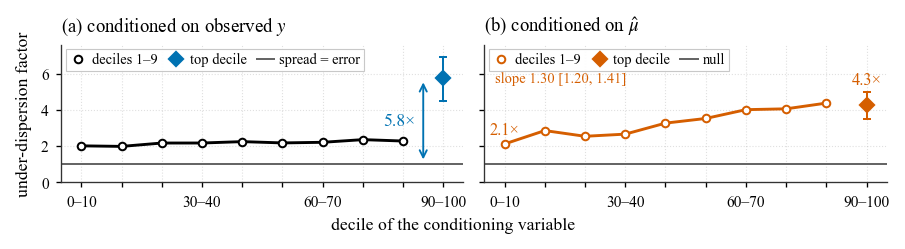

saved figures/workshop_v3_fig1_conditionings.{pdf,png}


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(FIGW, FIGH1), layout="constrained", sharey=True)
cc = np.arange(5, 100, 10)
YTOP = 7.6        # 7.4 originally, briefly 8.4. At FIGH1 = 1.40 the axes are tall enough
                  # that the legible legend row needs only a sliver of headroom, so this
                  # comes back down and the y-ticks return to the authored [0, 2, 4, 6].

def frame(ax, ref_label=None):
    ax.axhline(1.0, ls="-", lw=0.9, color=CREF, zorder=2, label=ref_label)
    ax.set_xlim(0, 100); ax.set_ylim(0, YTOP); ax.set_xticks(cc)
    ax.set_xticklabels([f"{k*10}–{k*10+10}" if k % 3 == 0 else "" for k in range(10)])
    ax.set_yticks([0, 2, 4, 6])

# ---------------- (a) conditioned on observed discharge ----------------
a0 = axs[0]
a0.plot(cc[:9], prof_y[:9], "-", color=CK, lw=1.3, zorder=5)
a0.plot(cc[:9], prof_y[:9], "o", ms=3.4, mfc="white", mec=CK, mew=0.9, zorder=6, label="deciles 1–9")
a0.errorbar(cc[9], prof_y[9], yerr=[[prof_y[9]-lo_y[9]], [hi_y[9]-prof_y[9]]],
            fmt="none", ecolor=CP, elinewidth=0.9, capsize=2.0, capthick=0.9, zorder=7)
a0.plot(cc[9], prof_y[9], "D", ms=4.4, mfc=CP, mec=CP, zorder=8, label="top decile")
a0.annotate("", xy=(cc[9]-5.0, prof_y[9]), xytext=(cc[9]-5.0, 1.0),
            arrowprops=dict(arrowstyle="<->", lw=0.85, color=CP), zorder=9)
a0.annotate(f"{prof_y[9]:.1f}×", xy=(cc[9]-7.0, (prof_y[9]+1.0)/2), fontsize=8, color=CP,
            ha="right", va="center")
frame(a0, ref_label="spread = error")
a0.set_ylabel("under-dispersion factor")
style_legend(a0.legend(loc="upper left", ncol=3, handlelength=1.2, borderpad=0.26,
                       labelspacing=0.15, handletextpad=0.35, columnspacing=0.7, fontsize=6.5))
a0.set_title(r"(a) conditioned on observed $y$", loc="left", fontsize=8.5)

# ---------------- (b) conditioned on the model's own prediction ----------------
a1 = axs[1]
a1.plot(cc[:9], prof_mu[:9], "-", color=CO, lw=1.3, zorder=5)
a1.plot(cc[:9], prof_mu[:9], "o", ms=3.4, mfc="white", mec=CO, mew=0.9, zorder=6, label="deciles 1–9")
a1.errorbar(cc[9], prof_mu[9], yerr=[[prof_mu[9]-lo_m[9]], [hi_m[9]-prof_mu[9]]],
            fmt="none", ecolor=CO, elinewidth=0.9, capsize=2.0, capthick=0.9, zorder=7)
a1.plot(cc[9], prof_mu[9], "D", ms=4.4, mfc=CO, mec=CO, zorder=8, label="top decile")
# above the point, not below: at a 0.75in axes height a 0.42-unit drop lands the label on
# the reference line at 1.0.
a1.annotate(f"{prof_mu[0]:.1f}×", xy=(cc[0], prof_mu[0]+0.30), fontsize=7.5, color=CO,
            ha="center", va="bottom")
a1.annotate(f"{prof_mu[9]:.1f}×", xy=(cc[9], hi_m[9]+0.22), fontsize=7.5, color=CO,
            ha="center", va="bottom")
frame(a1, ref_label="null")
_lg1 = style_legend(a1.legend(loc="upper left", ncol=3, handlelength=1.2, borderpad=0.26,
                              labelspacing=0.15, handletextpad=0.35, columnspacing=0.7,
                              fontsize=6.5))
under_legend(a1, _lg1, f"slope {b_mu:.2f} [{ci_b[0]:.2f}, {ci_b[1]:.2f}]",
             fontsize=6.5, color=CO)
a1.set_title(r"(b) conditioned on $\hat\mu$", loc="left", fontsize=8.5)

assert hi_y[9] <= YTOP and hi_m[9] <= YTOP, "top-decile error bar exceeds the frame"
assert max(prof_y.max(), prof_mu.max()) <= YTOP, "a plotted point exceeds the frame"
print(f"axis-limit gate passed: tallest element {max(hi_y[9], hi_m[9]):.2f}, frame top {YTOP}")

fig.supxlabel("decile of the conditioning variable", fontsize=8)
fig.savefig(FIG_OUT/"workshop_v3_fig1_conditionings.pdf")
fig.savefig(FIG_OUT/"workshop_v3_fig1_conditionings.png", dpi=400)
plt.show()
print("saved figures/workshop_v3_fig1_conditionings.{pdf,png}")

## Figure 2 — the metric passes anyway

**AUSE** (area under the sparsification error curve) is a *rank-based* metric: both the
spread-ordered and oracle curves are built by sorting, and the normalisation divides by the
random-to-oracle envelope. It is therefore **exactly invariant** under any strictly monotone
transform of the uncertainty, in particular under $\hat\sigma\mapsto c\,\hat\sigma$.

**That invariance is a theorem, not a result, and it does not get a panel.** It is verified below
to $10^{-12}$ so it can be asserted in one sentence of prose. Spending a figure panel proving a
definitional identity buys nothing a reader cannot check on paper.

What *is* empirical is whether the metric's verdict tracks the size error across basins — it need
not be blind in practice merely because it is blind in principle. Panel (b) answers that, and the
answer is worse than "uninformative": rank quality and size error are **negatively** associated.
The basins AUSE scores best are among the worst-sized, and **every** basin has a ratio above one
regardless of how it ranks. Report the universal statement as the claim and $\rho$ as support —
$\rho$ is modest and could carry a flow-variability confound.

**The two aggregate AUSE values are not directly comparable.** AUSE renormalises to the set it is
computed on, so conditioning on a subset changes the baseline and some degradation is mechanical.
Say "in aggregate, weakening at the tail" rather than claiming the ranking is correct.

                   set         n    AUSE   ratio
              all test   877,729   0.077    4.13
       top flow decile    87,930   0.268    5.76
    above training p90   100,974   0.245    5.65
    above training p99    13,295   0.308   10.40
  top $\hat\mu$ decile    87,961   0.207    4.27

invariance check: AUSE = 0.076906 at c = [np.float64(0.25), np.float64(1.0), np.float64(4.13), np.float64(16.0)], identical to 1e-12
  ratio would pass 1 at c = 4.13. Definitional -- state it, do not plot it.

PER-BASIN: rank quality vs size error  (269 basins)
  AUSE  median 0.182, range 0.026-0.661
  ratio median 2.33,  range 1.03-10.78   -> ratio > 1 in 269/269 basins
  Spearman rho = -0.331 (p = 2.8e-08) -- NEGATIVE:
    basins that rank BEST are sized WORST.
  best-AUSE decile  (<= 0.087): median ratio 3.53
  worst-AUSE decile (>= 0.336): median ratio 1.92
  of the 19 basins beating the pooled AUSE 0.077: 100% have ratio > 1, 95% have ratio > 2, median 3.47
  State rho as supporting; the una

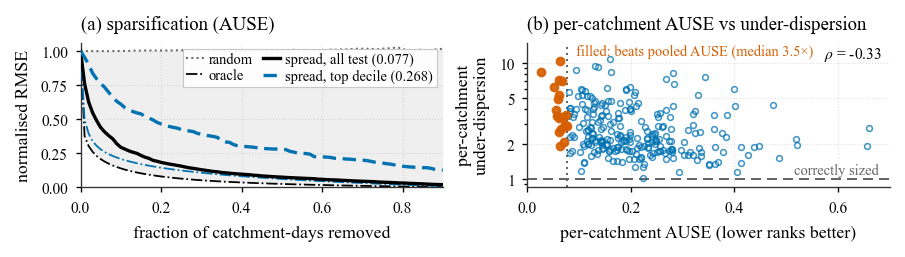

saved figures/workshop_v3_fig2_ause.{pdf,png}


In [7]:
def ause_parts(m, nf=21, seed=0, scale=1.0):
    se, e2v = sigma_e2[m]*scale**2, err2[m]; n = len(e2v)
    fr = np.linspace(0, 0.9, nf); rr = np.random.default_rng(seed)
    curve = lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp, co = curve(np.argsort(-se)), curve(np.argsort(-e2v))
    cr = np.mean([curve(rr.permutation(n)) for _ in range(10)], axis=0)
    num, den = np.trapezoid(cp-co, fr), np.trapezoid(cr-co, fr)
    return (num/den if den > 0 else np.nan), cp, co, cr, fr

qtr = np.nanpercentile(np.where(TRV, y, np.nan), [90, 99], axis=0)
SETS = {"all test": TEST,
        "top flow decile": TEST & (dec == 9),
        "above training p90": TEST & (y > np.broadcast_to(qtr[0], y.shape)),
        "above training p99": TEST & (y > np.broadcast_to(qtr[1], y.shape)),
        r"top $\hat\mu$ decile": TEST & (dec_mu == 9)}
print(f"{'set':>22s} {'n':>9s} {'AUSE':>7s} {'ratio':>7s}")
AU = {}
for nm_, m in SETS.items():
    a = ause_parts(m)[0]; AU[nm_] = {"n": int(m.sum()), "ause": float(a), "ratio": float(factor(m))}
    print(f"{nm_:>22s} {int(m.sum()):9,d} {a:7.3f} {factor(m):7.2f}")

# Invariance is a THEOREM, not a finding: both curves are built by sorting and the
# normalisation strips scale, so sigma -> c*sigma leaves AUSE bit-identical. Verified here
# so it can be asserted in one sentence of prose rather than spent as a figure panel.
cs = np.array([0.25, 1.0, float(factor(TEST)), 16.0])
au_c = np.array([ause_parts(TEST, scale=c)[0] for c in cs])
assert np.allclose(au_c, au_c[0], atol=1e-12), "AUSE is not invariant -- check the implementation"
print(f"\ninvariance check: AUSE = {au_c[0]:.6f} at c = {list(np.round(cs,2))}, identical to 1e-12")
print(f"  ratio would pass 1 at c = {factor(TEST):.2f}. Definitional -- state it, do not plot it.")

# ---- the EMPIRICAL claim: does ranking well predict being sized well? ----
def ause_vec(se, e2v, nf=21, seed=0):
    n = len(e2v)
    if n < 50: return np.nan
    fr = np.linspace(0, 0.9, nf); rr = np.random.default_rng(seed)
    curve = lambda o: np.array([np.sqrt(np.mean(e2v[o[int(f*n):]])) for f in fr])
    cp, co = curve(np.argsort(-se)), curve(np.argsort(-e2v))
    cr = np.mean([curve(rr.permutation(n)) for _ in range(10)], axis=0)
    num, den = np.trapezoid(cp-co, fr), np.trapezoid(cr-co, fr)
    return num/den if den > 0 else np.nan

pb_ause, pb_ratio = [], []
for j in range(NBAS):
    m = TEST[:, j]
    if m.sum() < 200: continue
    a = ause_vec(sigma_e2[m, j], err2[m, j])
    if not np.isfinite(a): continue
    pb_ause.append(a); pb_ratio.append(resid[m, j].std()/(np.sqrt(sigma_e2[m, j].mean())*CORR))
pb_ause, pb_ratio = np.array(pb_ause), np.array(pb_ratio)

from scipy.stats import spearmanr
rho = spearmanr(pb_ause, pb_ratio)
best = pb_ause <= AU["all test"]["ause"]
q10, q90 = np.quantile(pb_ause, [0.1, 0.9])
print(f"\nPER-BASIN: rank quality vs size error  ({len(pb_ause)} basins)")
print(f"  AUSE  median {np.median(pb_ause):.3f}, range {pb_ause.min():.3f}-{pb_ause.max():.3f}")
print(f"  ratio median {np.median(pb_ratio):.2f},  range {pb_ratio.min():.2f}-{pb_ratio.max():.2f}"
      f"   -> ratio > 1 in {int((pb_ratio>1).sum())}/{len(pb_ratio)} basins")
print(f"  Spearman rho = {rho.statistic:+.3f} (p = {rho.pvalue:.2g}) -- NEGATIVE:")
print(f"    basins that rank BEST are sized WORST.")
print(f"  best-AUSE decile  (<= {q10:.3f}): median ratio {np.median(pb_ratio[pb_ause<=q10]):.2f}")
print(f"  worst-AUSE decile (>= {q90:.3f}): median ratio {np.median(pb_ratio[pb_ause>=q90]):.2f}")
print(f"  of the {int(best.sum())} basins beating the pooled AUSE {AU['all test']['ause']:.3f}: "
      f"{100*np.mean(pb_ratio[best]>1):.0f}% have ratio > 1, "
      f"{100*np.mean(pb_ratio[best]>2):.0f}% have ratio > 2, median {np.median(pb_ratio[best]):.2f}")
print("  State rho as supporting; the unassailable claim is that EVERY basin has ratio > 1")
print(f"  (minimum {pb_ratio.min():.2f}) regardless of how well it ranks.")

fig, axs = plt.subplots(1, 2, figsize=(FIGW, FIGH2), layout="constrained", width_ratios=[1, 1])

# ---- (a) sparsification curves ----
# Each curve is normalised by its OWN set's full-sample RMSE, so random sits at 1.0 for both
# sets and one grey baseline serves both. Only the all-test random-to-oracle envelope is
# shaded -- that envelope is the AUSE denominator; drawing the numerator alone would make a
# comfortable pass read as a failure.
a0 = axs[0]
_, cp_a, co_a, cr_a, fr = ause_parts(SETS["all test"], nf=91)
_, cp_t, co_t, cr_t, _  = ause_parts(SETS["top flow decile"], nf=91)
a0.fill_between(fr, co_a/cr_a[0], cr_a/cr_a[0], color=CREF, alpha=0.10, lw=0, zorder=1)
a0.plot(fr, cr_a/cr_a[0], ls=":", color=CREF, lw=0.9, zorder=3, label="random")
a0.plot(fr, co_a/cr_a[0], ls="-.", color=CK, lw=0.8, zorder=3, label="oracle")
a0.plot(fr, co_t/cr_t[0], ls="-.", color=CP, lw=0.8, zorder=3)
a0.plot(fr, cp_a/cr_a[0], "-", color=CK, lw=1.5, zorder=4,
        label=f"spread, all test ({AU['all test']['ause']:.3f})")
a0.plot(fr, cp_t/cr_t[0], ls=(0, (4, 2)), color=CP, lw=1.5, zorder=4,
        label=f"spread, top decile ({AU['top flow decile']['ause']:.3f})")
a0.set_xlim(0, 0.9); a0.set_ylim(0, 1.06)
a0.set_xticks([0, 0.2, 0.4, 0.6, 0.8]); a0.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
a0.set_xlabel("fraction of catchment-days removed")
a0.set_ylabel("normalised RMSE")
# no legend title: "random" and "oracle" are orderings too, so a "spread-ordered" title
# would mislabel half the entries. Every row names its own ordering.
# two columns: at full width the panel is 2.4in and two columns keep the legend to two rows,
# which is what makes a 1.25in figure height viable -- spend the width on the legend, not on
# panel height.
style_legend(a0.legend(loc="upper right", bbox_to_anchor=(0.995, 0.99), ncol=2,
                       handlelength=1.2, borderpad=0.26, labelspacing=0.15, handletextpad=0.35,
                       columnspacing=0.7, fontsize=6.5))
a0.set_title("(a) sparsification (AUSE)", loc="left", fontsize=8.5)

# ---- (b) per-basin: ranking well does not mean being sized well ----
a1 = axs[1]
a1.axhline(1.0, ls=(0, (5, 3)), lw=0.9, color=CREF, zorder=2)
a1.axvline(AU["all test"]["ause"], ls=(0, (1, 2)), lw=0.9, color=CREF, zorder=2)
a1.plot(pb_ause[~best], pb_ratio[~best], "o", ms=2.6, mfc="none", mec=CP, mew=0.7,
        alpha=0.75, zorder=4)
a1.plot(pb_ause[best], pb_ratio[best], "o", ms=3.4, mfc=CO, mec=CO, alpha=0.9, zorder=5)
a1.set_yscale("log")
# ylim top 14 -> 15: one notch above the authored value, just enough that the legible
# annotation row clears the top of the cloud (max 10.5) without squashing it.
a1.set_xlim(0, 0.70); a1.set_ylim(0.85, 15)
a1.set_xticks([0, 0.2, 0.4, 0.6])
a1.set_yticks([1, 2, 5, 10]); a1.set_yticklabels(["1", "2", "5", "10"])
a1.annotate(f"$\\rho$ = {rho.statistic:+.2f}", xy=(0.98, 0.98), xycoords="axes fraction",
            fontsize=7, color=CK, ha="right", va="top")
# back on one line now that the panel is 2.4in wide, and started to the RIGHT of the
# pooled-AUSE rule at x = 0.077 so the text no longer crosses it.
a1.annotate(f"filled: beats pooled AUSE (median {np.median(pb_ratio[best]):.1f}×)",
            xy=(0.135, 0.99), xycoords="axes fraction", fontsize=6.5, color=CO,
            ha="left", va="top")
a1.annotate("correctly sized", xy=(0.68, 1.03), fontsize=6.5, color=CREF,
            ha="right", va="bottom")
a1.set_xlabel("per-catchment AUSE (lower ranks better)")
a1.set_ylabel("per-catchment\nunder-dispersion")   # two lines: rotated, so this costs
                                                   # width, not the height that is scarce
a1.set_title("(b) per-catchment AUSE vs under-dispersion", loc="left", fontsize=8.5)

fig.savefig(FIG_OUT/"workshop_v3_fig2_ause.pdf")
fig.savefig(FIG_OUT/"workshop_v3_fig2_ause.png", dpi=400)
plt.show()
print("saved figures/workshop_v3_fig2_ause.{pdf,png}")

FIGVALS["ause"] = {"sets": {k.replace("$", "").replace("\\hat\\mu", "mu-hat"): v
                            for k, v in AU.items()},
                   "invariance_c": cs.tolist(), "invariance_ause": au_c.tolist(),
                   "crossing_c": float(factor(TEST)),
                   "invariance_note": "definitional: AUSE is exactly invariant under "
                                      "sigma -> c*sigma; verified identical to 1e-12. Prose, not a panel.",
                   "per_basin": {"n": len(pb_ause), "spearman_rho": float(rho.statistic),
                                 "spearman_p": float(rho.pvalue),
                                 "ause_median": float(np.median(pb_ause)),
                                 "ratio_median": float(np.median(pb_ratio)),
                                 "ratio_min": float(pb_ratio.min()),
                                 "ratio_gt1": int((pb_ratio > 1).sum()),
                                 "n_beating_pooled_ause": int(best.sum()),
                                 "beating_ratio_median": float(np.median(pb_ratio[best])),
                                 "beating_pct_gt2": float(100*np.mean(pb_ratio[best] > 2)),
                                 "best_decile_ratio_median": float(np.median(pb_ratio[pb_ause <= q10])),
                                 "worst_decile_ratio_median": float(np.median(pb_ratio[pb_ause >= q90]))}}

## Table 1 — exceedance ladder and the detection ceiling

$y$-conditioned, against each basin's **training** flow distribution. Two things per row: the
observed ratio with its basin-clustered interval, and the detection ceiling — the fraction of
exceedance days the model's own prediction also flags. At the training maximum the model predicts
288 exceedance days against 603 observed.

In [8]:
# basin-clustered bootstrap on each ladder rung
def ladder_boot(cond, levels):
    rows = {}
    for i, lab in enumerate(LAB):
        m = TEST & (cond > levels[i][None, :] if levels[i].ndim == 1 else cond > levels[i])
        nj = m.sum(0).astype(float)
        sr = np.where(m, resid, 0).sum(0); sr2 = np.where(m, resid**2, 0).sum(0)
        ss = np.where(m, sigma_e2, 0).sum(0)
        def f_of(J):
            n = nj[J].sum()
            if n < 2: return np.nan
            return np.sqrt(sr2[J].sum()/n - (sr[J].sum()/n)**2)/(np.sqrt(ss[J].sum()/n)*CORR)
        bs = np.array([f_of(J) for J in J_boot])
        rows[lab] = {"n": int(m.sum()), "factor": float(f_of(np.arange(NBAS))),
                     "ci": [float(np.nanpercentile(bs, 2.5)), float(np.nanpercentile(bs, 97.5))]}
    return rows

lb_y  = ladder_boot(y,  tl_obs)
lb_mu = ladder_boot(mu, tl_mu)

print("TABLE 1 -- exceedance ladder, conditioned on observed discharge\n")
EXPFRAC = [0.10, 0.05, 0.01, 0.005, 0.001, 0.0]      # implied by the training distribution
NTEST = int(TEST.sum())
hdr = f"{'level':>8s} {'n':>8s} {'ratio':>6s} {'95% CI':>14s} {'expected':>9s} {'obs/exp':>8s}"
print(hdr); print("-"*len(hdr))
tab = []
for i, lab in enumerate(LAB):
    r = lb_y[lab]; nn = nlad[i]
    det = nl_m[i]/nl_y[i]
    e = EXPFRAC[i]*NTEST
    oe = f"{r['n']/e:.2f}" if e > 0 else "div by 0"
    print(f"{lab:>8s} {r['n']:8,d} {r['factor']:6.2f} [{r['ci'][0]:5.2f},{r['ci'][1]:5.2f}] "
          f"{e:9,.0f} {oe:>8s}")
    tab.append({"level": lab, "n": r["n"], "ratio": r["factor"], "ratio_ci": r["ci"],
                "null": float(nn), "excess": float(r["factor"]/nn),
                "n_expected": float(EXPFRAC[i]*NTEST),
                "obs_over_expected": (r["n"]/(EXPFRAC[i]*NTEST)) if EXPFRAC[i] > 0 else None,
                "mu_ratio": lb_mu[lab]["factor"], "mu_ratio_ci": lb_mu[lab]["ci"]})
print("\nobs/exp = observed exceedance days divided by what each basin's frozen 1980-2005")
print("training distribution implies for a test set of this size. It rises monotonically:")
print("the high-flow regime is visited more often than the training climate implies.")

print(f"\nmu-hat-conditioned ladder (move 3's frame), with the thin top levels bootstrapped")
print(f"{'level':>8s} {'n':>8s} {'ratio':>6s} {'95% CI':>14s}")
for lab in LAB:
    r = lb_mu[lab]
    print(f"{lab:>8s} {r['n']:8,d} {r['factor']:6.2f} [{r['ci'][0]:5.2f},{r['ci'][1]:5.2f}]")
print(f"  the 'max' rung has n = {lb_mu['max']['n']} and its interval "
      f"[{lb_mu['max']['ci'][0]:.2f}, {lb_mu['max']['ci'][1]:.2f}] overlaps the p99.9 rung's point "
      f"estimate ({lb_mu['p99.9']['factor']:.2f}):")
print("  the apparent drop at the top level is NOT established. Do not read it as recovery.")

FIGVALS["table1"] = tab
FIGVALS["mu_ladder"] = {k: lb_mu[k] for k in LAB}

# ---- LaTeX for the paper ----
print("\n" + "="*78 + "\nLaTeX (booktabs)\n" + "="*78)
cols = " & ".join(f"$>${t['level']}" for t in tab)
row_f = " & ".join(f"${t['ratio']:.2f}$" for t in tab)
row_c = " & ".join(f"$[{t['ratio_ci'][0]:.1f}, {t['ratio_ci'][1]:.1f}]$" for t in tab)
row_o = " & ".join(("--" if t["obs_over_expected"] is None else f"${t['obs_over_expected']:.2f}$") for t in tab)
row_n = " & ".join("$" + f"{t['n']:,}".replace(",", "{,}") + "$" for t in tab)
print(r"\begin{table}[!ht]")
print(r"\centering"); print(r"\small"); print(r"\setlength{\tabcolsep}{4pt}")
print(r"\caption{Ratio of residual standard deviation to reported ensemble spread against each "
      r"basin's frozen $1980$--$2005$ training flow distribution, conditioned on observed "
      r"discharge. Bins are cumulative: each column contains all test basin-days exceeding that "
      r"level. Intervals are basin-clustered bootstrap 95\% intervals ($B=1000$). The "
      r"obs/expected row divides the observed exceedance count by the count the training "
      r"distribution implies for a test set of this size.}")
print(r"\label{tab:exceedance}")
print(r"\begin{tabular}{lrrrrrr}"); print(r"\toprule")
print(f"& {cols} \\\\"); print(r"\midrule")
print(f"residual SD / spread & {row_f} \\\\")
print(f"95\\% CI & {row_c} \\\\")
print(f"obs / expected & {row_o} \\\\")
print(f"basin-days ($n$) & {row_n} \\\\")
print(r"\bottomrule"); print(r"\end{tabular}"); print(r"\end{table}")

# ---- footnote quantities ----
sd_k, rmse_k, s_k, meansd_k = (np.array(v) for v in zip(*[agg(S_y, k) for k in range(10)]))
lit_rmse = 10**np.mean(np.log10(rmse_k[:9]/s_k[:9]))
lit_mean = 10**np.mean(np.log10(sd_k[:9]/meansd_k[:9]))
print("\nFOOTNOTE -- literal axis readings a reviewer will recompute:")
print(f"  y = RMSE instead of residual SD          -> bulk offset {lit_rmse:.3f}x "
      f"(reintroduces bias, forfeits mean-independence)")
print(f"  x = arithmetic mean of member SD          -> bulk offset {lit_mean:.3f}x "
      f"(inflated: variances add, standard deviations do not)")
print(f"  spread definition: sqrt(mean sigma_e^2) * sqrt((M+1)/M), M = {M}, factor {CORR:.4f}")
FIGVALS["footnote"] = {"offset_if_rmse": float(lit_rmse), "offset_if_mean_member_sd": float(lit_mean)}

FIGVALS["limitations"] = [
    "Aleatoric variance is excluded from the denominator; this is a statement about "
    "inter-member spread only.",
    "The null is Gaussian and independent across basin-days; a heavier-tailed draw would "
    "raise it and shrink the reported excess.",
    "Analysis is in linear discharge units. Member-level outputs were not retained, so a "
    "log-transform robustness check is not available.",
    "The ratio is bounded below by an unknown aleatoric variance under both conditionings, "
    "so its level is a lower bound on the dispersion shortfall rather than a point estimate.",
    "Discharge is derived through a rating relation; stable systematic rating error is learned "
    "into mu-hat rather than appearing in the residual.",
]
(FIG_OUT/"figure_values_v3.json").write_text(json.dumps(FIGVALS, indent=2))
print(f"\nwrote figures/figure_values_v3.json ({len(json.dumps(FIGVALS)):,} bytes)")

TABLE 1 -- exceedance ladder, conditioned on observed discharge

   level        n  ratio         95% CI  expected  obs/exp
----------------------------------------------------------
     p90  100,974   5.65 [ 4.36, 6.77]    87,773     1.15
     p95   55,212   6.79 [ 5.19, 8.23]    43,886     1.26
     p99   13,295  10.40 [ 7.96,12.60]     8,777     1.51
   p99.5    7,185  11.99 [ 9.14,14.55]     4,389     1.64
   p99.9    2,023  14.41 [10.95,17.83]       878     2.30
     max      603  17.93 [12.94,23.36]         0 div by 0

obs/exp = observed exceedance days divided by what each basin's frozen 1980-2005
training distribution implies for a test set of this size. It rises monotonically:
the high-flow regime is visited more often than the training climate implies.

mu-hat-conditioned ladder (move 3's frame), with the thin top levels bootstrapped
   level        n  ratio         95% CI
     p90   98,388   4.23 [ 3.47, 4.90]
     p95   53,573   4.28 [ 3.58, 4.94]
     p99   11,750   4.38 

## Appendix D.2 — Figure 2 data tables

Same purpose as the Figure 1 ledger: every plotted quantity in a form a reviewer can
recompute. Two tables, because the two panels are different objects.

**(a) sparsification.** The curves are drawn on a 91-point grid; the table gives every tenth
point, so the tabulated values *are* plotted values, not a re-derivation. Each set is
normalised by its own full-sample RMSE, so all three orderings start at 1.000 and the AUSE
ratio is unaffected — the normalisation cancels in numerator and denominator.

**One thing the table forces into the open:** the AUSE figures quoted in the body
(0.077 / 0.268) are computed on the **21-point** grid, while the curves are drawn at 91
points. Trapezoid on the finer grid gives slightly larger values. Both are reported below so
a reviewer integrating the tabulated curve lands on the number the caption claims.

**(b) per-catchment scatter.** 269 points, so a row-per-catchment table is not a table. What
is tabulated instead is the scatter *binned by AUSE decile* — which is the panel's actual
claim (rank quality does not buy correct sizing) in the smallest honest form. The full
per-catchment arrays go into `figure_values_v3.json` so the scatter itself stays reproducible
without spending five appendix pages on it.


In [9]:
# ---------------- Appendix D.2: the data behind Figure 2 ----------------
IDX = np.arange(0, 91, 10)                      # every tenth point of the drawn 91-pt curve
assert len(fr) == 91 and abs(fr[IDX][-1] - 0.9) < 1e-12, "curve grid is not the 91-pt grid"
R0a, R0t = cr_a[0], cr_t[0]                     # each set's own full-sample RMSE, mm/day
Pa, Oa, Ra = cp_a[IDX]/R0a, co_a[IDX]/R0a, cr_a[IDX]/R0a
Pt, Ot, Rt = cp_t[IDX]/R0t, co_t[IDX]/R0t, cr_t[IDX]/R0t

def texp(p, sig=1):
    """p-value as LaTeX. '2.8e-08' inside $...$ renders as a literal 'e', not a power."""
    e = int(np.floor(np.log10(p))); m = p/10**e
    return rf"{m:.{sig}f}\times 10^{{{e}}}"

# AUSE on both grids, so the caption can state which one the body number is
au91_a = ause_parts(SETS["all test"],        nf=91)[0]
au91_t = ause_parts(SETS["top flow decile"], nf=91)[0]
au21_a, au21_t = AU["all test"]["ause"], AU["top flow decile"]["ause"]

print("APPENDIX D.2 (a) -- sparsification curves, normalised by each set's full-sample RMSE")
print(f"  all test   n = {AU['all test']['n']:,}   full-sample RMSE = {R0a:.3f} mm/day")
print(f"  top decile n = {AU['top flow decile']['n']:,}   full-sample RMSE = {R0t:.3f} mm/day")
print(f"  AUSE  21-pt grid (body): all test {au21_a:.3f}, top decile {au21_t:.3f}")
print(f"        91-pt grid (drawn): all test {au91_a:.3f}, top decile {au91_t:.3f}")
print(f"  random ordering departs from 1.000 by at most "
      f"{max(np.abs(Ra-1).max(), np.abs(Rt-1).max()):.4f} -- it is flat by construction\n")
hdr = (f"{'removed':>8s} | {'spread':>7s} {'oracle':>7s} {'random':>7s} | "
       f"{'spread':>7s} {'oracle':>7s} {'random':>7s}")
print(hdr); print(f"{'':>8s} | {'------ all test ------':^25s} | {'----- top decile -----':^25s}")
for i, f_ in enumerate(fr[IDX]):
    print(f"{f_:8.1f} | {Pa[i]:7.3f} {Oa[i]:7.3f} {Ra[i]:7.3f} | {Pt[i]:7.3f} {Ot[i]:7.3f} {Rt[i]:7.3f}")

# ---- (b) the 269-point scatter, binned by AUSE decile ----
q = np.quantile(pb_ause, np.linspace(0, 1, 11))
q[-1] += 1e-9                                   # closed top bin
bin_of = np.clip(np.searchsorted(q, pb_ause, side="right") - 1, 0, 9)
print(f"\nAPPENDIX D.2 (b) -- {len(pb_ause)} catchments (>= 200 test days), binned by AUSE decile")
print(f"  Spearman rho = {rho.statistic:+.3f} (p = {rho.pvalue:.2g});  "
      f"under-dispersion > 1 in {int((pb_ratio>1).sum())}/{len(pb_ratio)}, min {pb_ratio.min():.2f}")
print(f"{'AUSE decile':>12s} {'n':>4s} {'AUSE range':>15s} {'median':>8s} {'min':>7s} {'max':>7s}")
B4ROWS = []
for k in range(10):
    m = bin_of == k
    r_ = pb_ratio[m]; a_ = pb_ause[m]
    print(f"{k*10:4d}-{k*10+10:<7d} {int(m.sum()):4d} "
          f"[{a_.min():.3f}, {a_.max():.3f}] {np.median(r_):8.2f} {r_.min():7.2f} {r_.max():7.2f}")
    B4ROWS.append(dict(decile=k+1, n=int(m.sum()), ause_lo=float(a_.min()), ause_hi=float(a_.max()),
                       ratio_median=float(np.median(r_)), ratio_min=float(r_.min()),
                       ratio_max=float(r_.max())))
_med = np.array([r_["ratio_median"] for r_ in B4ROWS])
_inv = [k+1 for k in range(9) if _med[k+1] > _med[k]]
print(f"  best AUSE decile median {_med[0]:.2f}x vs worst {_med[-1]:.2f}x -- ranking better does"
      f" not size better. Decline is NOT monotone; inverts after bin(s) {_inv}")

# ---------------- LaTeX ----------------
tex = lambda v: f"{v:,}".replace(",", "{,}")
print("\n" + "="*78 + "\nLaTeX -- Appendix D.2\n" + "="*78)
print(r"\subsection{Figure 2} \label{sec:figure2_datatable}")
print(r"\begin{table}[H]"); print(r"    \centering"); print(r"    \small")
print(r"    \setlength{\tabcolsep}{5pt}")
print(r"    \caption{Sparsification curves behind Figure~2(a), on the plotted 91-point grid "
      r"sampled every tenth point. Retained RMSE is normalised by each set's own full-sample "
      r"RMSE ($" + f"{R0a:.3f}" + r"$~mm/day for all test, $" + f"{R0t:.3f}" + r"$~mm/day for the "
      r"top flow decile), so every ordering starts at $1.000$; the normalisation cancels in "
      r"numerator and denominator and leaves AUSE unchanged. \emph{Spread} orders basin-days by "
      r"reported ensemble variance, \emph{oracle} by realised squared error, \emph{random} by a "
      r"seeded permutation averaged over ten draws, which is flat to within $" +
      f"{max(np.abs(Ra-1).max(), np.abs(Rt-1).max()):.3f}" + r"$ rather than exactly flat. "
      r"AUSE quoted in the body ($" +
      f"{au21_a:.3f}" + r"$ all test, $" + f"{au21_t:.3f}" + r"$ top decile) uses a 21-point "
      r"grid; integrating the 91-point curve tabulated here gives $" + f"{au91_a:.3f}" +
      r"$ and $" + f"{au91_t:.3f}" + r"$. $n = " + tex(AU['all test']['n']) + r"$ and $n = " +
      tex(AU['top flow decile']['n']) + r"$ catchment-days.}")
print(r"    \label{tab:sparsification_data}")
print(r"    \begin{tabular}{lrrrcrrr}")
print(r"    \toprule")
print(r"    & \multicolumn{3}{c}{all test} & & \multicolumn{3}{c}{top flow decile} \\")
print(r"    \cmidrule(lr){2-4}\cmidrule(lr){6-8}")
print(r"    fraction removed & spread & oracle & random & & spread & oracle & random \\")
print(r"    \midrule")
for i, f_ in enumerate(fr[IDX]):
    print(f"    ${f_:.1f}$ & ${Pa[i]:.3f}$ & ${Oa[i]:.3f}$ & ${Ra[i]:.3f}$ & "
          f"& ${Pt[i]:.3f}$ & ${Ot[i]:.3f}$ & ${Rt[i]:.3f}$ \\\\")
print(r"    \bottomrule"); print(r"    \end{tabular}"); print(r"\end{table}")

print()
print(r"\begin{table}[H]"); print(r"    \centering"); print(r"    \small")
print(r"    \setlength{\tabcolsep}{5pt}")
print(r"    \caption{The " + str(len(pb_ause)) + r" catchments of Figure~2(b), binned into "
      r"deciles of per-catchment AUSE. A row per catchment is not tabulable at this length, so "
      r"the panel's claim is given in its smallest form: sorting catchments by how well their "
      r"spread \emph{ranks} error does not sort them by how well it is \emph{sized}. "
      r"Under-dispersion is the same ratio as elsewhere, computed within each catchment; "
      r"Spearman $\rho = " + f"{rho.statistic:+.2f}" + r"$ ($p = " + texp(rho.pvalue) +
      r"$). The decline is not monotone -- " + str(len(_inv)) + r" of the nine steps invert -- "
      r"but every catchment exceeds the "
      r"null of~$1$, minimum $" + f"{pb_ratio.min():.2f}" + r"$. The $200$-test-day minimum "
      r"excludes no catchment here; all $" + str(NBAS) + r"$ are retained. Full per-catchment "
      r"values are in \texttt{figure\_values\_v3.json}.}")
print(r"    \label{tab:perbasin_data}")
print(r"    \begin{tabular}{lrcrrr}")
print(r"    \toprule")
print(r"    & & & \multicolumn{3}{c}{under-dispersion} \\")
print(r"    \cmidrule(lr){4-6}")
print(r"    AUSE decile & $n$ & AUSE range & median & min & max \\")
print(r"    \midrule")
for r_ in B4ROWS:
    k = r_["decile"]
    print(f"    {(k-1)*10}--{k*10} & ${r_['n']}$ & $[{r_['ause_lo']:.3f}, {r_['ause_hi']:.3f}]$ "
          f"& ${r_['ratio_median']:.2f}$ & ${r_['ratio_min']:.2f}$ & ${r_['ratio_max']:.2f}$ \\\\")
print(r"    \bottomrule"); print(r"    \end{tabular}"); print(r"\end{table}")

FIGVALS["appendix_d2"] = {
    "panel_a": {"fraction_removed": fr[IDX].tolist(),
                "all_test":   {"spread": Pa.tolist(), "oracle": Oa.tolist(), "random": Ra.tolist(),
                               "rmse_full_sample": float(R0a), "n": AU["all test"]["n"],
                               "ause_21pt": float(au21_a), "ause_91pt": float(au91_a)},
                "top_decile": {"spread": Pt.tolist(), "oracle": Ot.tolist(), "random": Rt.tolist(),
                               "rmse_full_sample": float(R0t), "n": AU["top flow decile"]["n"],
                               "ause_21pt": float(au21_t), "ause_91pt": float(au91_t)},
                "note": "normalised by each set's own full-sample RMSE; AUSE is invariant to it"},
    "panel_b": {"bins_by_ause_decile": B4ROWS,
                "per_catchment_ause": [round(float(v), 5) for v in pb_ause],
                "per_catchment_ratio": [round(float(v), 4) for v in pb_ratio],
                "min_test_days": 200,
                "note": "arrays are positionally aligned; one entry per retained catchment"}}
(FIG_OUT/"figure_values_v3.json").write_text(json.dumps(FIGVALS, indent=2))
print(f"\nrewrote figures/figure_values_v3.json ({len(json.dumps(FIGVALS)):,} bytes) "
      f"with appendix_d2 (including the {len(pb_ause)} per-catchment pairs)")


APPENDIX D.2 (a) -- sparsification curves, normalised by each set's full-sample RMSE
  all test   n = 877,729   full-sample RMSE = 2.017 mm/day
  top decile n = 87,930   full-sample RMSE = 5.765 mm/day
  AUSE  21-pt grid (body): all test 0.077, top decile 0.268
        91-pt grid (drawn): all test 0.084, top decile 0.276
  random ordering departs from 1.000 by at most 0.0162 -- it is flat by construction

 removed |  spread  oracle  random |  spread  oracle  random
         |  ------ all test ------   |  ----- top decile -----  
     0.0 |   1.000   1.000   1.000 |   1.000   1.000   1.000
     0.1 |   0.294   0.139   1.000 |   0.610   0.208   1.002
     0.2 |   0.183   0.080   1.003 |   0.465   0.144   0.997
     0.3 |   0.129   0.052   1.002 |   0.389   0.107   0.998
     0.4 |   0.097   0.036   0.999 |   0.302   0.081   0.997
     0.5 |   0.075   0.025   1.002 |   0.279   0.062   0.997
     0.6 |   0.059   0.017   1.005 |   0.223   0.045   0.998
     0.7 |   0.045   0.011   1.016 |  

## The thesis, in the numbers this notebook computes

> Ten LSTMs trained on identical data disagree with one another, and that disagreement is reported
> as the model's uncertainty. Conditioning on observed discharge, the uncertainty window misses
> actual floods by nearly sixfold. Three things could produce that: the selection inherent in
> choosing days by outcome, mean bias, and dispersion error. We quantify the first by simulation
> and subtract it. The second is established for this architecture and we acknowledge it without
> addressing it. The third we isolate by conditioning on the model's own prediction, which nulls
> conditional mean error by construction. The failure persists: spread too narrow by twofold at
> ordinary flows, fourfold at the highest flows the model anticipates, growing with flow but too
> slowly, in 226 of 269 basins. Correcting the known peak bias does not close it. The standard
> check on a reported spread tests only whether it flags the right days, not whether it is the
> right size, so this passes at 0.07 while being wrong by a factor of four. A perfect mean forecast
> would not fix this. And the regime where it is most wrong is the one a warming climate visits
> more often.

Every quantity in that paragraph is a ratio, a count, a simulated null, or AUSE. Nothing here fits
a scaling exponent, estimates an attenuation coefficient, or reports a regression-derived
dispersion parameter. Statistics that do not carry a sentence above are not computed.

Do **not** write: "uncertainty is underestimated", "epistemic uncertainty", "true uncertainty",
bare "calibrated", bare "identified", or "no regime where the ensemble is honest".